# Лабораторная работа 1: Классификация цвета автомобиля

## Задача
Классификация цвета автомобиля на датасете DVM (Deep Visual Marketing).

## Цели работы:
1. Написать ResNet с нуля и обучить на датасете DVM
2. Дообучить 2 предобученных классификатора на ImageNet
3. Оценить качество через F1_macro (требуется > 0.8)
4. Сравнить качество всех классификаторов между собой

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import platform
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except Exception:
    IN_COLAB = False

USE_FAST_MODE = False
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
PIN_MEMORY = True
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None

print(f'Режим: {"обычный (GPU)"}')
print(f'Размер входа: {IMAGE_SIZE}x{IMAGE_SIZE}, batch_size={BATCH_SIZE}, num_workers={NUM_WORKERS}')

Режим: обычный (GPU)
Размер входа: 224x224, batch_size=32, num_workers=4


In [3]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    DATA_DIR = '/content/drive/MyDrive/lab1_data'
else:
    pass

Mounted at /content/drive
Датасет в Colab: /content/drive/MyDrive/lab1_data


## Часть 1: Реализация ResNet с нуля

In [8]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000, num_channels=3):
        super(ResNet, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(num_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(channels * block.expansion)
            )
        layers = []
        layers.append(block(self.in_channels, channels, stride, downsample))
        self.in_channels = channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def resnet34(num_classes=1000, num_channels=3):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, num_channels=num_channels)

print("ResNet архитектура реализована!")

ResNet архитектура реализована!


In [9]:
def load_pretrained_model(model_name, num_classes):
    if model_name == 'mobilenet_v3_small':
        try:
            from torchvision.models import MobileNet_V3_Small_Weights
            model = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        except (ImportError, AttributeError):
            model = models.mobilenet_v3_small(pretrained=True)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
        return model

    try:
        from torchvision.models import ResNet50_Weights
        if model_name == 'resnet50':
            model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        else:
            raise ValueError(f"Неизвестная модель: {model_name}")
    except (ImportError, AttributeError):
        if model_name == 'resnet50':
            model = models.resnet50(pretrained=True)
        else:
            raise ValueError(f"Неизвестная модель: {model_name}")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

print("Функция загрузки предобученных моделей создана!")

Функция загрузки предобученных моделей создана!


## Часть 2: Загрузка и обработка датасета DVM

In [10]:
class DVMDataset(Dataset):

    def __init__(self, root_dir, transform=None, split='train', use_reduced_classes=True):
        self.root_dir = root_dir
        self.transform = transform
        self.split = split
        self.use_reduced_classes = use_reduced_classes

        # Полный набор (14 классов)
        all_colors = [
            'beige', 'black', 'blue', 'brown', 'gold', 'green',
            'grey', 'orange', 'pink', 'purple', 'red', 'silver',
            'white', 'yellow'
        ]
        # Сокращённый набор (10 классов): мелкие объединяем, чтобы не портить F1 macro
        # beige->brown, gold->yellow, pink->red, purple->blue
        if use_reduced_classes:
            self.color_classes = ['black', 'blue', 'brown', 'green', 'grey', 'orange', 'red', 'silver', 'white', 'yellow']
            self._merge_to_reduced = {'beige': 'brown', 'gold': 'yellow', 'pink': 'red', 'purple': 'blue'}
        else:
            self.color_classes = all_colors
            self._merge_to_reduced = {}
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.color_classes)}
        self.idx_to_class = {idx: cls for idx, cls in enumerate(self.color_classes)}


        self.color_mapping = {
            'navy': 'blue',
            'turquoise': 'blue',
            'indigo': 'blue',
            'maroon': 'red',
            'burgundy': 'red',
            'magenta': 'pink',
            'bronze': 'brown',
            'multicolour': None,
            'unlisted': None
        }


        self.samples = self._load_samples()

        print(f"Загружено {len(self.samples)} образцов для {split}")
        print(f"Классы: {self.color_classes}")

    def _normalize_color(self, color):
        color = color.lower().strip()
        if color in self.color_classes:
            return color
        if color in self._merge_to_reduced:
            return color
        if color in self.color_mapping:
            return self.color_mapping[color]
        return None

    def _load_samples(self):
        samples = []


        for root, dirs, files in os.walk(self.root_dir):
            for filename in files:
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):

                    parts = filename.split('$$')
                    if len(parts) >= 4:
                        color_raw = parts[3].lower().strip()
                        color_normalized = self._normalize_color(color_raw)

                        # Пропускаем нестандартные цвета
                        if color_normalized is None:
                            continue

                        # Сокращённые классы: объединяем мелкие
                        if self._merge_to_reduced:
                            color_normalized = self._merge_to_reduced.get(color_normalized, color_normalized)
                        if color_normalized not in self.class_to_idx:
                            continue
                        img_path = os.path.join(root, filename)
                        label = self.class_to_idx[color_normalized]
                        samples.append((img_path, label))

        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Ошибка загрузки изображения {img_path}: {e}")
            # Возвращаем черное изображение в случае ошибки
            image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color='black')

        if self.transform:
            image = self.transform(image)

        return image, label


def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Сумма долей должна быть равна 1"

    np.random.seed(random_seed)
    indices = np.random.permutation(len(dataset))

    train_size = int(len(dataset) * train_ratio)
    val_size = int(len(dataset) * val_ratio)

    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]

    return train_indices, val_indices, test_indices


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Класс датасета создан!")

Класс датасета создан!


In [11]:
if 'DATA_DIR' not in globals():
    DATA_DIR = 'data'

if not os.path.exists(DATA_DIR):
    print(f"Директория {DATA_DIR} не найдена!")

    num_classes = 14
    full_dataset = None
else:
    print("Загрузка датасета...")
    full_dataset = DVMDataset(DATA_DIR, transform=train_transform, split='train')

    if len(full_dataset) > 0:
        # Разделяем на train/val/test
        train_indices, val_indices, test_indices = split_dataset(full_dataset)

        if MAX_TRAIN_SAMPLES is not None:
            train_indices = train_indices[:MAX_TRAIN_SAMPLES]
        if MAX_VAL_SAMPLES is not None:
            val_indices = val_indices[:MAX_VAL_SAMPLES]
        if MAX_TEST_SAMPLES is not None:
            test_indices = test_indices[:MAX_TEST_SAMPLES]


        train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
        val_dataset = torch.utils.data.Subset(full_dataset, val_indices)
        test_dataset = torch.utils.data.Subset(full_dataset, test_indices)

        # Обновляем трансформации для валидации и теста
        val_dataset.dataset.transform = val_test_transform
        test_dataset.dataset.transform = val_test_transform

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

        num_classes = len(full_dataset.color_classes)
        print(f"\nДатасет загружен успешно!")
        print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
        print(f"Количество классов: {num_classes}")

        # Распределение по классам и веса для баланса
        from collections import Counter
        train_labels = [full_dataset.samples[i][1] for i in train_indices]
        label_counts = Counter(train_labels)
        print("\nРаспределение классов в train:")
        for idx, count in sorted(label_counts.items()):
            print(f"  {full_dataset.idx_to_class[idx]}: {count}")
        n_cls = len(full_dataset.color_classes)
        total = len(train_labels)
        class_weights = torch.tensor([total / (n_cls * label_counts.get(i, 1)) for i in range(n_cls)], dtype=torch.float32)
    else:
        class_weights = None
        print("Датасет пуст! Проверьте структуру директорий.")
        num_classes = 14

Загрузка датасета...
Загружено 21843 образцов для train
Классы: ['black', 'blue', 'brown', 'green', 'grey', 'orange', 'red', 'silver', 'white', 'yellow']

Датасет загружен успешно!
Train: 15290, Val: 3276, Test: 3277
Количество классов: 10

Распределение классов в train:
  black: 3282
  blue: 2373
  brown: 598
  green: 248
  grey: 2425
  orange: 203
  red: 1591
  silver: 1947
  white: 2341
  yellow: 282

Веса классов (inverse frequency) для CrossEntropyLoss — помогают редким классам.


In [12]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    pbar = tqdm(train_loader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': running_loss / len(train_loader), 'acc': 100 * correct / total})

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_acc, f1


def validate(model, val_loader, criterion, device):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': running_loss / len(val_loader), 'acc': 100 * correct / total})

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_acc, f1


def evaluate_model(model, test_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Вычисляем метрики
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    accuracy = 100 * sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)

    report = classification_report(all_labels, all_preds, target_names=class_names)

    cm = confusion_matrix(all_labels, all_preds)

    return {
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'accuracy': accuracy,
        'predictions': all_preds,
        'labels': all_labels,
        'classification_report': report,
        'confusion_matrix': cm
    }


def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))


    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)


    axes[1].plot(history['train_acc'], label='Train Acc')
    axes[1].plot(history['val_acc'], label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True)


    axes[2].plot(history['train_f1'], label='Train F1 Macro')
    axes[2].plot(history['val_f1'], label='Val F1 Macro')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Macro')
    axes[2].set_title('Training and Validation F1 Macro')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

print("Функции для обучения и оценки созданы!")

Функции для обучения и оценки созданы!


## Часть 4: Обучение ResNet с нуля

Начало обучения ResNet34 с нуля...
Количество параметров: 21,289,802

Эпоха 1/30
--------------------------------------------------


Validation: 100%|██████████| 103/103 [05:20<00:00,  3.11s/it, loss=1.76, acc=30.6]


Train Loss: 1.5440, Train Acc: 43.45%, Train F1: 0.3853
Val Loss: 1.7628, Val Acc: 30.56%, Val F1: 0.2643

Эпоха 2/30
--------------------------------------------------


Validation: 100%|██████████| 103/103 [00:19<00:00,  5.41it/s, loss=1.24, acc=46]


Train Loss: 1.2770, Train Acc: 53.07%, Train F1: 0.4867
Val Loss: 1.2424, Val Acc: 45.97%, Val F1: 0.4672

Эпоха 3/30
--------------------------------------------------


...

Train Loss: 0.1528, Train Acc: 93.26%, Train F1: 0.9398
Val Loss: 0.6333, Val Acc: 84.49%, Val F1: 0.8142

Эпоха 29/30
--------------------------------------------------


Validation: 100%|██████████| 103/103 [00:19<00:00,  5.35it/s, loss=0.656, acc=84.6]


Train Loss: 0.1434, Train Acc: 93.53%, Train F1: 0.9453
Val Loss: 0.6559, Val Acc: 84.62%, Val F1: 0.8228

Эпоха 30/30
--------------------------------------------------


Validation: 100%|██████████| 103/103 [00:19<00:00,  5.39it/s, loss=0.669, acc=85]


Train Loss: 0.1350, Train Acc: 94.13%, Train F1: 0.9506
Val Loss: 0.6690, Val Acc: 84.98%, Val F1: 0.8218


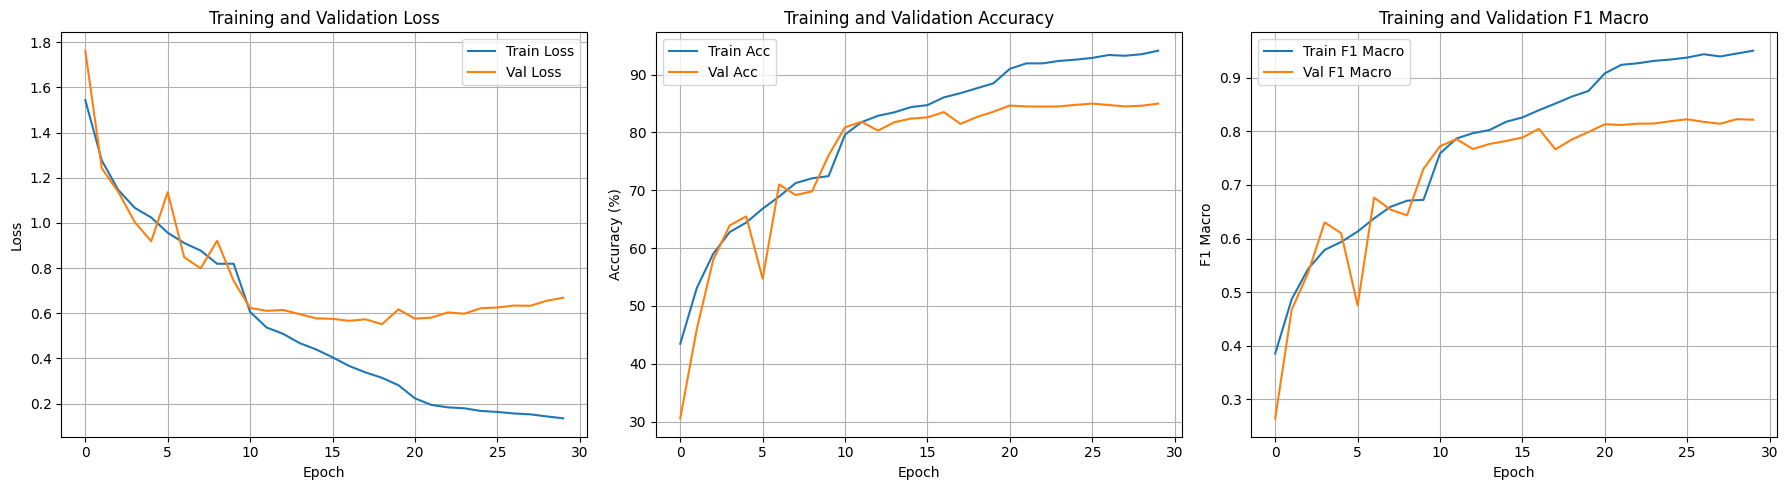


Оценка ResNet34 с нуля на тестовом наборе:


Evaluating: 100%|██████████| 103/103 [04:50<00:00,  2.82s/it]


F1 Macro: 0.8223
F1 Micro: 0.8447
Accuracy: 84.47%

Classification Report:
              precision    recall  f1-score   support

       black       0.83      0.89      0.86       713
        blue       0.86      0.82      0.84       522
       brown       0.73      0.63      0.67       147
       green       0.87      0.85      0.86        55
        grey       0.76      0.75      0.75       497
      orange       0.63      0.76      0.69        54
         red       0.96      0.94      0.95       341
      silver       0.84      0.81      0.83       421
       white       0.92      0.94      0.93       477
      yellow       0.83      0.86      0.84        50

    accuracy                           0.84      3277
   macro avg       0.82      0.82      0.82      3277
weighted avg       0.84      0.84      0.84      3277



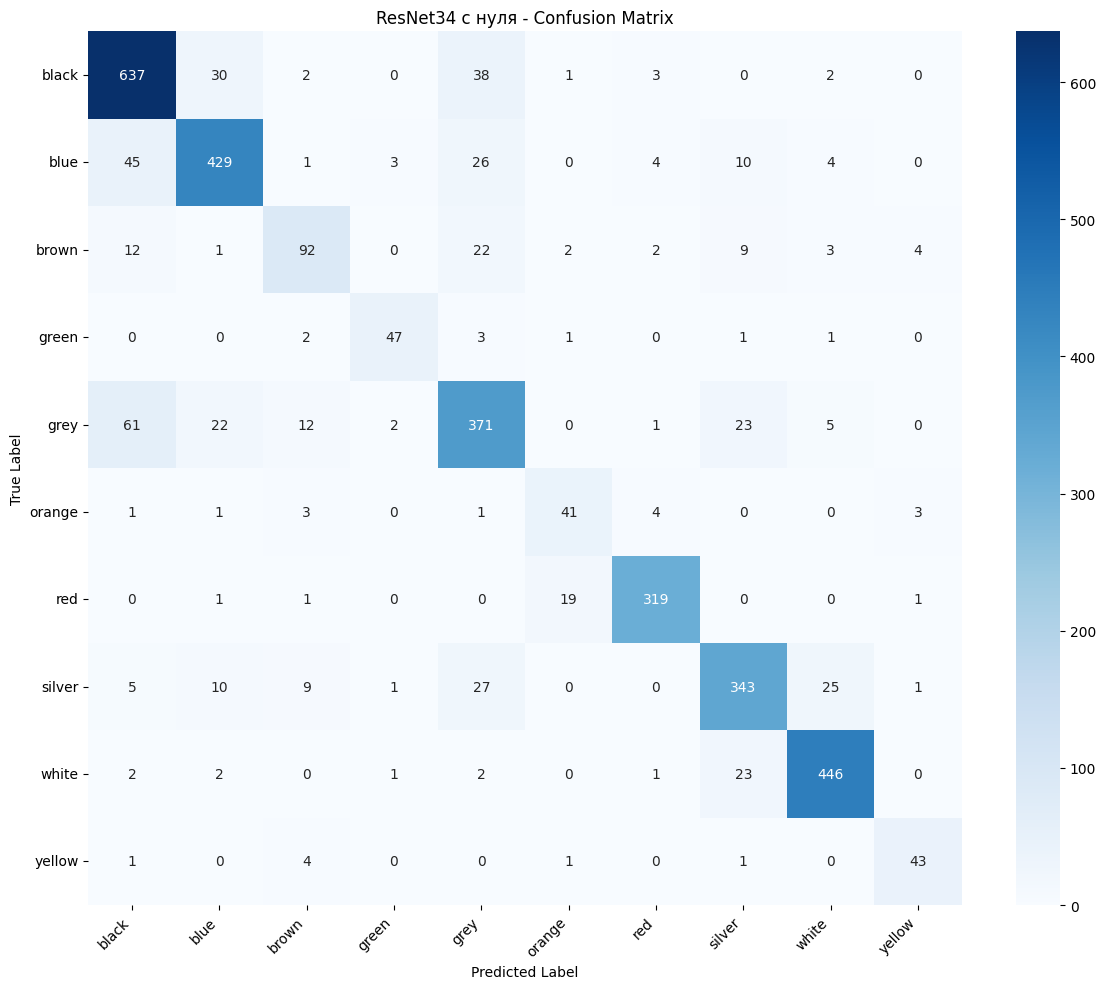

In [10]:
if 'full_dataset' in locals() and full_dataset is not None and len(full_dataset) > 0:
    model_from_scratch = resnet34(num_classes=num_classes, num_channels=3).to(device)

    # Функция потерь
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)
    optimizer = optim.Adam(model_from_scratch.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    history_scratch = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }

    num_epochs = 10 if USE_FAST_MODE else 30
    best_val_f1 = 0.0
    patience = 5
    patience_counter = 0

    print("Начало обучения ResNet34 с нуля...")
    print(f"Количество параметров: {sum(p.numel() for p in model_from_scratch.parameters()):,}")

    for epoch in range(num_epochs):
        print(f'\nЭпоха {epoch+1}/{num_epochs}')
        print('-' * 50)


        train_loss, train_acc, train_f1 = train_epoch(
            model_from_scratch, train_loader, criterion, optimizer, device
        )


        val_loss, val_acc, val_f1 = validate(
            model_from_scratch, val_loader, criterion, device
        )


        scheduler.step()


        history_scratch['train_loss'].append(train_loss)
        history_scratch['train_acc'].append(train_acc)
        history_scratch['train_f1'].append(train_f1)
        history_scratch['val_loss'].append(val_loss)
        history_scratch['val_acc'].append(val_acc)
        history_scratch['val_f1'].append(val_f1)

        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Train F1: {train_f1:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val F1: {val_f1:.4f}')


        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0

            torch.save(model_from_scratch.state_dict(), 'best_model_scratch.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping на эпохе {epoch+1}')
                break


    model_from_scratch.load_state_dict(torch.load('best_model_scratch.pth'))


    plot_training_history(history_scratch)


    print("\nОценка ResNet34 с нуля на тестовом наборе:")
    results_scratch = evaluate_model(model_from_scratch, test_loader, device, full_dataset.color_classes)
    print(f"F1 Macro: {results_scratch['f1_macro']:.4f}")
    print(f"F1 Micro: {results_scratch['f1_micro']:.4f}")
    print(f"Accuracy: {results_scratch['accuracy']:.2f}%")
    print("\nClassification Report:")
    print(results_scratch['classification_report'])


    plot_confusion_matrix(results_scratch['confusion_matrix'],
                         full_dataset.color_classes,
                         title='ResNet34 с нуля - Confusion Matrix')
else:
    print("Датасет не загружен. Пропускаем обучение.")

## Часть 5: Дообучение предобученных моделей

In [11]:
if 'full_dataset' in locals() and full_dataset is not None and len(full_dataset) > 0:
    print("Загрузка предобученного MobileNetV3 Small...")
    model_pretrained_mobilenet3 = load_pretrained_model('mobilenet_v3_small', num_classes)
    model_pretrained_mobilenet3 = model_pretrained_mobilenet3.to(device)
    print("Загрузка предобученного ResNet50...")
    model_pretrained_resnet50 = load_pretrained_model('resnet50', num_classes)
    model_pretrained_resnet50 = model_pretrained_resnet50.to(device)

    print(f"MobileNetV3 Small параметров: {sum(p.numel() for p in model_pretrained_mobilenet3.parameters()):,}")
    print(f"ResNet50 параметров: {sum(p.numel() for p in model_pretrained_resnet50.parameters()):,}")
else:
    print("Датасет не загружен. Пропускаем загрузку моделей.")

Загрузка предобученного MobileNetV3 Small...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 122MB/s]

Загрузка предобученного ResNet50...


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


MobileNetV3 Small параметров: 1,528,106
ResNet50 параметров: 23,528,522



ДООБУЧЕНИЕ ResNet50 (предобученная на ImageNet)

Эпоха 1/15
--------------------------------------------------


Validation: 100%|██████████| 103/103 [00:20<00:00,  5.03it/s, loss=0.906, acc=66.5]


Train Loss: 1.2413, Train Acc: 58.37%, Train F1: 0.5366
Val Loss: 0.9061, Val Acc: 66.48%, Val F1: 0.6373

Эпоха 2/15
--------------------------------------------------


Validation: 100%|██████████| 103/103 [00:19<00:00,  5.17it/s, loss=0.926, acc=68.1]


Train Loss: 0.9039, Train Acc: 67.08%, Train F1: 0.6384
Val Loss: 0.9258, Val Acc: 68.10%, Val F1: 0.6453

Эпоха 3/15
--------------------------------------------------


...

Train Loss: 0.0161, Train Acc: 99.43%, Train F1: 0.9953
Val Loss: 0.4011, Val Acc: 92.61%, Val F1: 0.9132

Финальное дообучение - Эпоха 9/10
--------------------------------------------------


Validation: 100%|██████████| 103/103 [00:19<00:00,  5.37it/s, loss=0.435, acc=92.2]


Train Loss: 0.0100, Train Acc: 99.69%, Train F1: 0.9980
Val Loss: 0.4349, Val Acc: 92.22%, Val F1: 0.9095

Финальное дообучение - Эпоха 10/10
--------------------------------------------------


Validation: 100%|██████████| 103/103 [00:19<00:00,  5.36it/s, loss=0.456, acc=92.4]


Train Loss: 0.0075, Train Acc: 99.78%, Train F1: 0.9983
Val Loss: 0.4559, Val Acc: 92.43%, Val F1: 0.9118


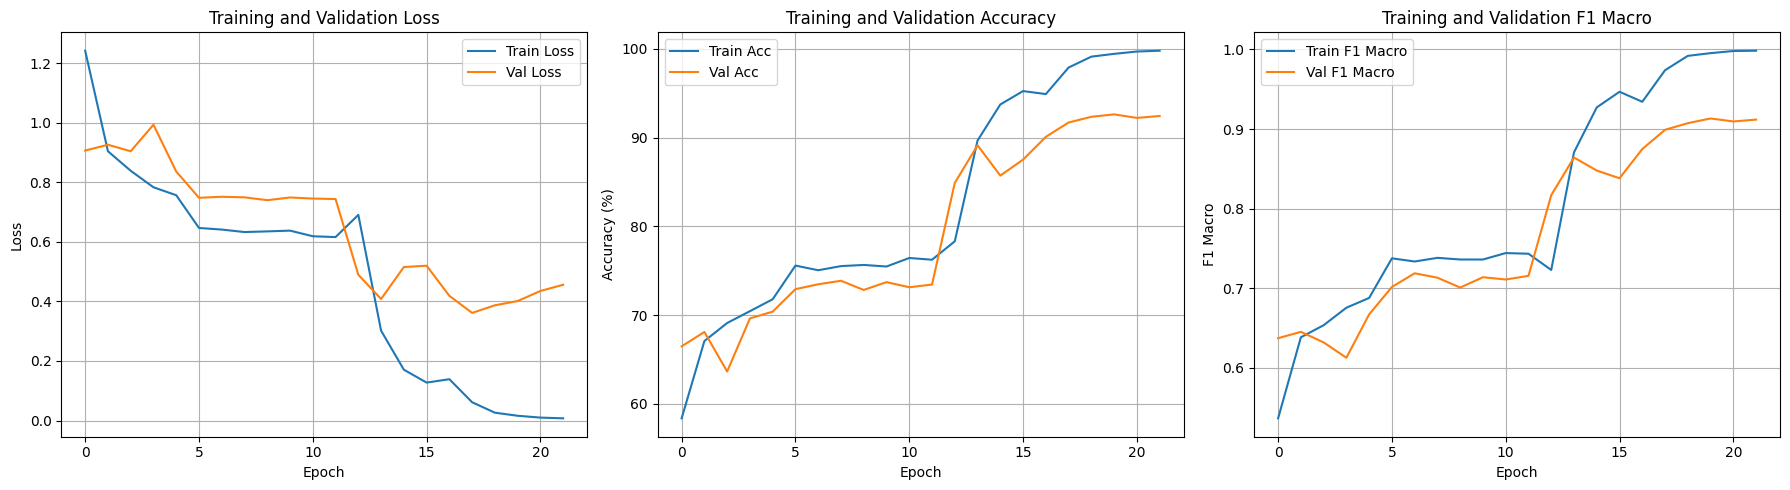


Оценка предобученного ResNet50 на тестовом наборе:


Evaluating: 100%|██████████| 103/103 [00:19<00:00,  5.35it/s]


F1 Macro: 0.9042
F1 Micro: 0.9234
Accuracy: 92.34%

Classification Report:
              precision    recall  f1-score   support

       black       0.92      0.96      0.94       713
        blue       0.94      0.90      0.92       522
       brown       0.79      0.82      0.80       147
       green       0.91      0.89      0.90        55
        grey       0.89      0.87      0.88       497
      orange       0.91      0.80      0.85        54
         red       0.97      0.98      0.97       341
      silver       0.92      0.92      0.92       421
       white       0.97      0.97      0.97       477
      yellow       0.90      0.88      0.89        50

    accuracy                           0.92      3277
   macro avg       0.91      0.90      0.90      3277
weighted avg       0.92      0.92      0.92      3277



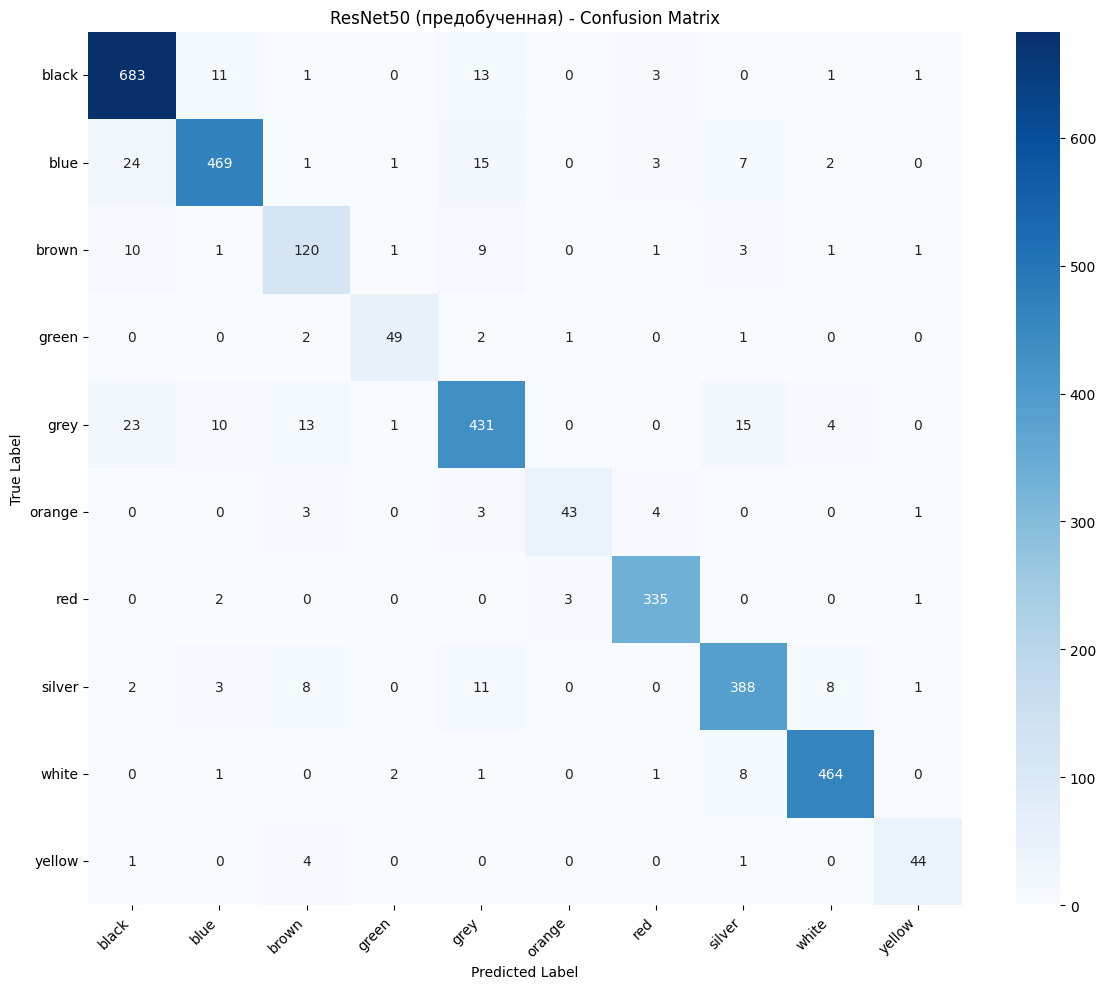

In [12]:
if 'full_dataset' in locals() and full_dataset is not None and len(full_dataset) > 0:
    print("\n" + "="*60)
    print("ДООБУЧЕНИЕ ResNet50 (предобученная на ImageNet)")
    print("="*60)

    # Замораживаем все слои кроме финального
    for param in model_pretrained_resnet50.parameters():
        param.requires_grad = False
    for param in model_pretrained_resnet50.fc.parameters():
        param.requires_grad = True

    optimizer_resnet50 = optim.Adam(model_pretrained_resnet50.fc.parameters(), lr=0.001)
    scheduler_resnet50 = optim.lr_scheduler.StepLR(optimizer_resnet50, step_size=5, gamma=0.1)

    history_resnet50 = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }

    num_epochs_finetune = 8 if USE_FAST_MODE else 15
    best_val_f1_resnet50 = 0.0
    patience_counter = 0
    patience = 5

    for epoch in range(num_epochs_finetune):
        print(f'\nЭпоха {epoch+1}/{num_epochs_finetune}')
        print('-' * 50)

        train_loss, train_acc, train_f1 = train_epoch(
            model_pretrained_resnet50, train_loader, criterion, optimizer_resnet50, device
        )

        val_loss, val_acc, val_f1 = validate(
            model_pretrained_resnet50, val_loader, criterion, device
        )

        scheduler_resnet50.step()

        history_resnet50['train_loss'].append(train_loss)
        history_resnet50['train_acc'].append(train_acc)
        history_resnet50['train_f1'].append(train_f1)
        history_resnet50['val_loss'].append(val_loss)
        history_resnet50['val_acc'].append(val_acc)
        history_resnet50['val_f1'].append(val_f1)

        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Train F1: {train_f1:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val F1: {val_f1:.4f}')

        if val_f1 > best_val_f1_resnet50:
            best_val_f1_resnet50 = val_f1
            patience_counter = 0
            torch.save(model_pretrained_resnet50.state_dict(), 'best_model_resnet50.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping на эпохе {epoch+1}')
                break

    # Размораживаем все слои для финального дообучения
    print("\nРазмораживание всех слоев для финального дообучения...")
    for param in model_pretrained_resnet50.parameters():
        param.requires_grad = True

    optimizer_resnet50_full = optim.Adam(model_pretrained_resnet50.parameters(), lr=0.0001, weight_decay=1e-4)
    scheduler_resnet50_full = optim.lr_scheduler.StepLR(optimizer_resnet50_full, step_size=5, gamma=0.1)

    num_epochs_full = 5 if USE_FAST_MODE else 10
    for epoch in range(num_epochs_full):
        print(f'\nФинальное дообучение - Эпоха {epoch+1}/{num_epochs_full}')
        print('-' * 50)

        train_loss, train_acc, train_f1 = train_epoch(
            model_pretrained_resnet50, train_loader, criterion, optimizer_resnet50_full, device
        )

        val_loss, val_acc, val_f1 = validate(
            model_pretrained_resnet50, val_loader, criterion, device
        )

        scheduler_resnet50_full.step()

        history_resnet50['train_loss'].append(train_loss)
        history_resnet50['train_acc'].append(train_acc)
        history_resnet50['train_f1'].append(train_f1)
        history_resnet50['val_loss'].append(val_loss)
        history_resnet50['val_acc'].append(val_acc)
        history_resnet50['val_f1'].append(val_f1)

        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Train F1: {train_f1:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val F1: {val_f1:.4f}')

        if val_f1 > best_val_f1_resnet50:
            best_val_f1_resnet50 = val_f1
            torch.save(model_pretrained_resnet50.state_dict(), 'best_model_resnet50.pth')

    model_pretrained_resnet50.load_state_dict(torch.load('best_model_resnet50.pth'))

    plot_training_history(history_resnet50)

    print("\nОценка предобученного ResNet50 на тестовом наборе:")
    results_resnet50 = evaluate_model(model_pretrained_resnet50, test_loader, device, full_dataset.color_classes)
    print(f"F1 Macro: {results_resnet50['f1_macro']:.4f}")
    print(f"F1 Micro: {results_resnet50['f1_micro']:.4f}")
    print(f"Accuracy: {results_resnet50['accuracy']:.2f}%")
    print("\nClassification Report:")
    print(results_resnet50['classification_report'])

    plot_confusion_matrix(results_resnet50['confusion_matrix'],
                         full_dataset.color_classes,
                         title='ResNet50 (предобученная) - Confusion Matrix')


ДООБУЧЕНИЕ MobileNetV3 Small (предобученная на ImageNet)

Эпоха 1/3
--------------------------------------------------


Validation: 100%|██████████| 103/103 [00:17<00:00,  5.86it/s, loss=0.711, acc=75.6]


Train Loss: 0.5334, Train Acc: 77.91%, Train F1: 0.7710
Val Loss: 0.7106, Val Acc: 75.64%, Val F1: 0.7264

Эпоха 2/3
--------------------------------------------------


Validation: 100%|██████████| 103/103 [00:17<00:00,  5.79it/s, loss=0.691, acc=77.7]


Train Loss: 0.4660, Train Acc: 80.05%, Train F1: 0.7950
Val Loss: 0.6912, Val Acc: 77.69%, Val F1: 0.7529

Эпоха 3/3
--------------------------------------------------


...

Train Loss: 0.1672, Train Acc: 92.77%, Train F1: 0.9345
Val Loss: 0.6156, Val Acc: 86.02%, Val F1: 0.8436

Финальное дообучение MobileNetV3 Small - Эпоха 4/5
--------------------------------------------------


Validation: 100%|██████████| 103/103 [00:17<00:00,  5.78it/s, loss=0.548, acc=86.5]


Train Loss: 0.1364, Train Acc: 93.93%, Train F1: 0.9472
Val Loss: 0.5478, Val Acc: 86.54%, Val F1: 0.8440

Финальное дообучение MobileNetV3 Small - Эпоха 5/5
--------------------------------------------------


Validation: 100%|██████████| 103/103 [00:19<00:00,  5.36it/s, loss=0.612, acc=87.1]


Train Loss: 0.1076, Train Acc: 95.06%, Train F1: 0.9610
Val Loss: 0.6122, Val Acc: 87.06%, Val F1: 0.8576


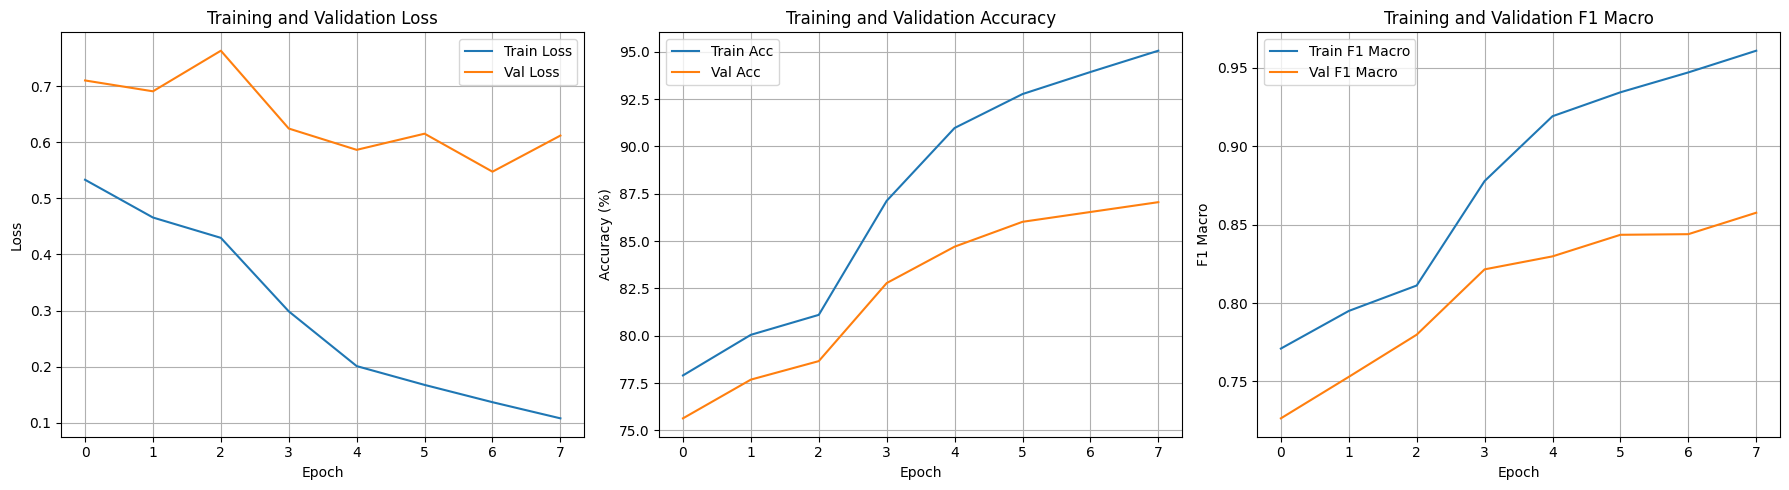


Оценка предобученного MobileNetV3 Small на тестовом наборе:


Evaluating: 100%|██████████| 103/103 [00:17<00:00,  5.81it/s]


F1 Macro: 0.8417
F1 Micro: 0.8633
Accuracy: 86.33%

Classification Report:
              precision    recall  f1-score   support

       black       0.84      0.88      0.86       713
        blue       0.91      0.84      0.87       522
       brown       0.76      0.68      0.72       147
       green       0.90      0.82      0.86        55
        grey       0.76      0.77      0.77       497
      orange       0.69      0.76      0.73        54
         red       0.94      0.94      0.94       341
      silver       0.86      0.90      0.88       421
       white       0.95      0.95      0.95       477
      yellow       0.86      0.84      0.85        50

    accuracy                           0.86      3277
   macro avg       0.85      0.84      0.84      3277
weighted avg       0.86      0.86      0.86      3277



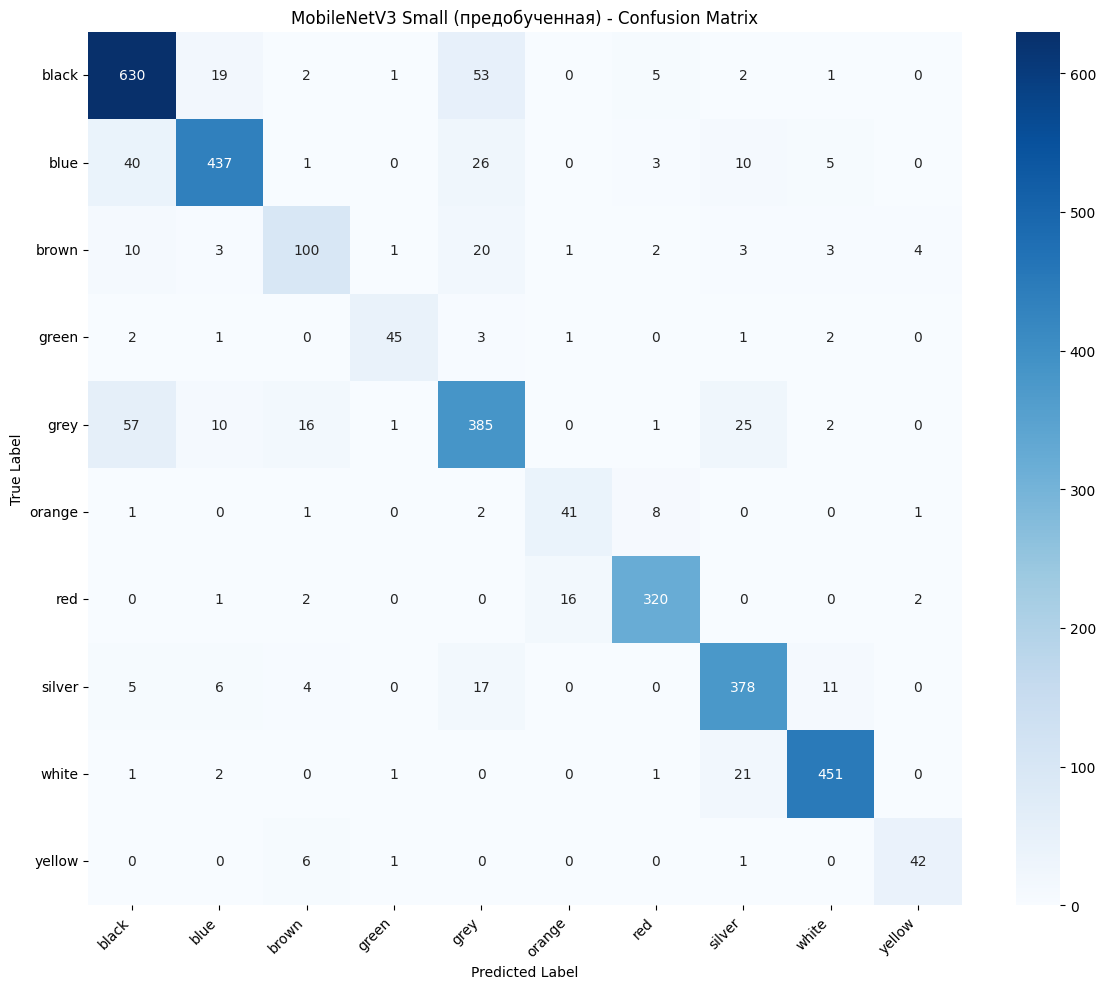

In [15]:
if 'full_dataset' in locals() and full_dataset is not None and len(full_dataset) > 0:
    print("\n" + "="*60)
    print("ДООБУЧЕНИЕ MobileNetV3 Small (предобученная на ImageNet)")
    print("="*60)

    for param in model_pretrained_mobilenet3.parameters():
        param.requires_grad = False
    for param in model_pretrained_mobilenet3.classifier.parameters():
        param.requires_grad = True

    optimizer_mobilenet3 = optim.Adam(model_pretrained_mobilenet3.classifier.parameters(), lr=0.001)
    scheduler_mobilenet3 = optim.lr_scheduler.StepLR(optimizer_mobilenet3, step_size=5, gamma=0.1)

    history_mobilenet3 = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }

    num_epochs_finetune = 8 if USE_FAST_MODE else 3
    best_val_f1_mobilenet3 = 0.0
    patience_counter = 0
    patience = 5

    for epoch in range(num_epochs_finetune):
        print(f'\nЭпоха {epoch+1}/{num_epochs_finetune}')
        print('-' * 50)
        train_loss, train_acc, train_f1 = train_epoch(
            model_pretrained_mobilenet3, train_loader, criterion, optimizer_mobilenet3, device
        )
        val_loss, val_acc, val_f1 = validate(
            model_pretrained_mobilenet3, val_loader, criterion, device
        )
        scheduler_mobilenet3.step()
        history_mobilenet3['train_loss'].append(train_loss)
        history_mobilenet3['train_acc'].append(train_acc)
        history_mobilenet3['train_f1'].append(train_f1)
        history_mobilenet3['val_loss'].append(val_loss)
        history_mobilenet3['val_acc'].append(val_acc)
        history_mobilenet3['val_f1'].append(val_f1)
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Train F1: {train_f1:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val F1: {val_f1:.4f}')
        if val_f1 > best_val_f1_mobilenet3:
            best_val_f1_mobilenet3 = val_f1
            patience_counter = 0
            torch.save(model_pretrained_mobilenet3.state_dict(), 'best_model_mobilenet3.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping на эпохе {epoch+1}')
                break

    print("\nРазмораживание всех слоев для финального дообучения...")
    for param in model_pretrained_mobilenet3.parameters():
        param.requires_grad = True
    optimizer_mobilenet3_full = optim.Adam(model_pretrained_mobilenet3.parameters(), lr=0.0001, weight_decay=1e-4)
    scheduler_mobilenet3_full = optim.lr_scheduler.StepLR(optimizer_mobilenet3_full, step_size=5, gamma=0.1)
    num_epochs_full = 5 if USE_FAST_MODE else 5
    for epoch in range(num_epochs_full):
        print(f'\nФинальное дообучение MobileNetV3 Small - Эпоха {epoch+1}/{num_epochs_full}')
        print('-' * 50)
        train_loss, train_acc, train_f1 = train_epoch(
            model_pretrained_mobilenet3, train_loader, criterion, optimizer_mobilenet3_full, device
        )
        val_loss, val_acc, val_f1 = validate(
            model_pretrained_mobilenet3, val_loader, criterion, device
        )
        scheduler_mobilenet3_full.step()
        history_mobilenet3['train_loss'].append(train_loss)
        history_mobilenet3['train_acc'].append(train_acc)
        history_mobilenet3['train_f1'].append(train_f1)
        history_mobilenet3['val_loss'].append(val_loss)
        history_mobilenet3['val_acc'].append(val_acc)
        history_mobilenet3['val_f1'].append(val_f1)
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Train F1: {train_f1:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val F1: {val_f1:.4f}')
        if val_f1 > best_val_f1_mobilenet3:
            best_val_f1_mobilenet3 = val_f1
            torch.save(model_pretrained_mobilenet3.state_dict(), 'best_model_mobilenet3.pth')

    model_pretrained_mobilenet3.load_state_dict(torch.load('best_model_mobilenet3.pth'))
    plot_training_history(history_mobilenet3)

    print("\nОценка предобученного MobileNetV3 Small на тестовом наборе:")
    results_mobilenet3 = evaluate_model(model_pretrained_mobilenet3, test_loader, device, full_dataset.color_classes)
    print(f"F1 Macro: {results_mobilenet3['f1_macro']:.4f}")
    print(f"F1 Micro: {results_mobilenet3['f1_micro']:.4f}")
    print(f"Accuracy: {results_mobilenet3['accuracy']:.2f}%")
    print("\nClassification Report:")
    print(results_mobilenet3['classification_report'])
    plot_confusion_matrix(results_mobilenet3['confusion_matrix'], full_dataset.color_classes, title='MobileNetV3 Small (предобученная) - Confusion Matrix')

## Часть 6: Сравнение результатов всех классификаторов

## Выводы

На основе проведённого эксперимента можно сделать следующие выводы:

1. **Сравнение архитектур**: Предобученные модели показывают значительно лучшие результаты по сравнению с моделью, обученной с нуля, что ожидаемо, так как они уже имеют полезные представления, извлечённые из большого датасета ImageNet.

2. **Сравнение предобученных моделей**: ResNet50 и MobileNetV3 Small дают разный компромисс между числом параметров, скоростью и качеством классификации цвета.

3. **Эффективность transfer learning**: Дообучение предобученных моделей позволяет достичь высокого качества даже при ограниченном количестве данных, что является основным преимуществом transfer learning.


In [16]:
if 'full_dataset' in locals() and full_dataset is not None and len(full_dataset) > 0:
    if 'results_scratch' in locals() and 'results_mobilenet3' in locals() and 'results_resnet50' in locals():
        print("\n" + "="*80)
        print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ВСЕХ КЛАССИФИКАТОРОВ")
        print("="*80)
        comparison_results = {
            'Модель': ['ResNet34 с нуля', 'MobileNetV3 Small (предобученная)', 'ResNet50 (предобученная)'],
            'F1 Macro': [results_scratch['f1_macro'], results_mobilenet3['f1_macro'], results_resnet50['f1_macro']],
            'F1 Micro': [results_scratch['f1_micro'], results_mobilenet3['f1_micro'], results_resnet50['f1_micro']],
            'Accuracy (%)': [results_scratch['accuracy'], results_mobilenet3['accuracy'], results_resnet50['accuracy']]
        }
        print("\nТаблица сравнения:")
        print("-" * 80)
        print(f"{'Модель':<32} {'F1 Macro':<12} {'F1 Micro':<12} {'Accuracy (%)':<12}")
        print("-" * 80)
        for i, name in enumerate(comparison_results['Модель']):
            print(f"{name:<32} {comparison_results['F1 Macro'][i]:<12.4f} {comparison_results['F1 Micro'][i]:<12.4f} {comparison_results['Accuracy (%)'][i]:<12.2f}")
        print("-" * 80)
        models_names = comparison_results['Модель']
        f1_macro_values = comparison_results['F1 Macro']
        best_idx = np.argmax(f1_macro_values)
        print(f"\nЛучшая модель по F1 Macro: {models_names[best_idx]} ({f1_macro_values[best_idx]:.4f})")
        print("\nПроверка требования F1_macro > 0.8:")
        for i, name in enumerate(models_names):
            status = "✓ выполнено" if f1_macro_values[i] > 0.8 else "✗ не достигнуто"
            print(f"  {name}: {f1_macro_values[i]:.4f} {status}")
    else:
        print("Не все модели обучены. Запустите ячейки: ResNet с нуля, Дообучение MobileNetV3, Дообучение ResNet50.")
else:
    print("Датасет не загружен.")


СРАВНЕНИЕ РЕЗУЛЬТАТОВ ВСЕХ КЛАССИФИКАТОРОВ

Таблица сравнения:
--------------------------------------------------------------------------------
Модель                           F1 Macro     F1 Micro     Accuracy (%)
--------------------------------------------------------------------------------
ResNet34 с нуля                  0.8223       0.8447       84.47       
MobileNetV3 Small (предобученная) 0.8417       0.8633       86.33       
ResNet50 (предобученная)         0.9042       0.9234       92.34       
--------------------------------------------------------------------------------

Лучшая модель по F1 Macro: ResNet50 (предобученная) (0.9042)

Проверка требования F1_macro > 0.8:
  ResNet34 с нуля: 0.8223 ✓ выполнено
  MobileNetV3 Small (предобученная): 0.8417 ✓ выполнено
  ResNet50 (предобученная): 0.9042 ✓ выполнено


## Часть 7: Демонстрация инференса на своих изображениях


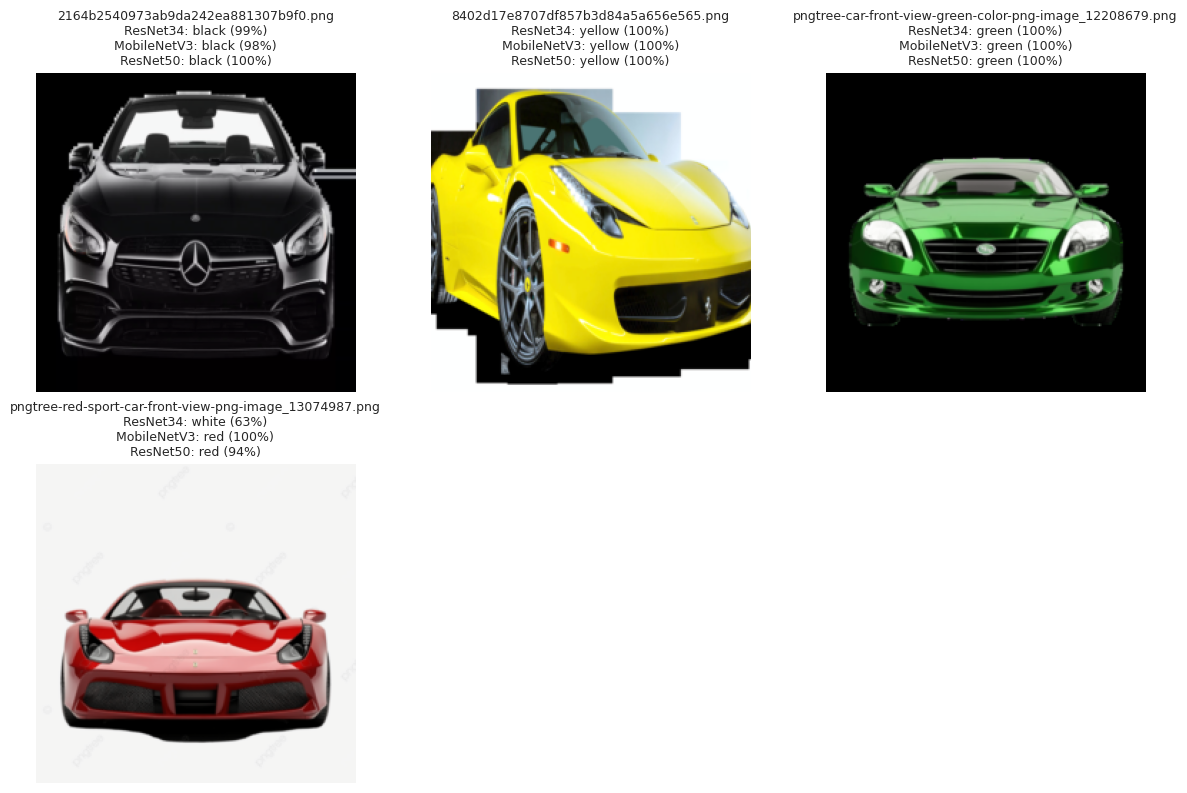

In [27]:
from PIL import ImageOps

INF_DATA_DIR = 'inf_data'
CLASS_NAMES = ['black', 'blue', 'brown', 'green', 'grey', 'orange', 'red', 'silver', 'white', 'yellow']
num_classes = len(CLASS_NAMES)

sz = globals().get('IMAGE_SIZE', 224)
inf_transform = transforms.Compose([
    transforms.Resize((sz + 32, sz + 32)), transforms.CenterCrop(sz),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def _m(name):
    return globals()[name] if name in globals() else None
if _m('model_from_scratch') is None:
    model_from_scratch = resnet34(num_classes=num_classes, num_channels=3).to(device)
    model_from_scratch.load_state_dict(torch.load('best_model_scratch.pth', map_location=device))
if _m('model_pretrained_mobilenet3') is None:
    model_pretrained_mobilenet3 = load_pretrained_model('mobilenet_v3_small', num_classes).to(device)
    model_pretrained_mobilenet3.load_state_dict(torch.load('best_model_mobilenet3.pth', map_location=device))
if _m('model_pretrained_resnet50') is None:
    model_pretrained_resnet50 = load_pretrained_model('resnet50', num_classes).to(device)
    model_pretrained_resnet50.load_state_dict(torch.load('best_model_resnet50.pth', map_location=device))

paths = []
if os.path.isdir(INF_DATA_DIR):
    paths = [os.path.join(INF_DATA_DIR, f) for f in sorted(os.listdir(INF_DATA_DIR))
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
else:
    os.makedirs(INF_DATA_DIR, exist_ok=True)
    print(f"Создана папка {INF_DATA_DIR}. Положите туда .png или .jpg и запустите ячейку снова.")
if not paths:
    print(f"В папке {INF_DATA_DIR} нет .png или .jpg")
else:
    tensors = []
    for p in paths:
        img = Image.open(p).convert('RGB')
        img = ImageOps.exif_transpose(img)
        tensors.append(inf_transform(img))
    batch = torch.stack(tensors).to(device)

    def run(model, batch, names):
        model.eval()
        with torch.no_grad():
            logits = model(batch)
            probs = torch.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)
        return [names[p] for p in pred.cpu().numpy()], conf.cpu().numpy()

    p1, c1 = run(model_from_scratch, batch, CLASS_NAMES)
    p2, c2 = run(model_pretrained_mobilenet3, batch, CLASS_NAMES)
    p3, c3 = run(model_pretrained_resnet50, batch, CLASS_NAMES)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    n = len(paths)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).flatten()
    for i in range(n):
        t = tensors[i].permute(1, 2, 0).numpy() * std + mean
        axes[i].imshow(np.clip(t, 0, 1))
        axes[i].axis('off')
        axes[i].set_title(f"{os.path.basename(paths[i])}\nResNet34: {p1[i]} ({c1[i]:.0%})\nMobileNetV3: {p2[i]} ({c2[i]:.0%})\nResNet50: {p3[i]} ({c3[i]:.0%})", fontsize=9)
    for j in range(n, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()
